In [1]:
import pandas as pd
from utils import show_missing_values, cramers_v_matrix, cat_corr_heatmap, num_corr_heatmap

In [2]:
df = pd.read_pickle('data/exploded_crime_data.pkl')
show_missing_values(df)

,Column Name,Min,Max,n Unique,NaN count,NaN percentage,dtype
S. No.,,,,,,,
1,report_number,10304468,252104053,853344,0,0.0%,int64
2,date_reported,nan,nan,1860,0,0.0%,datetime64[ns]
3,area_code,nan,nan,21,0,0.0%,category
4,area_name,nan,nan,21,0,0.0%,object
5,report_district_number,nan,nan,1199,0,0.0%,category
6,part,nan,nan,2,0,0.0%,category
7,crime_description,nan,nan,139,0,0.0%,object
8,modus_operandi_code,nan,nan,739,0,0.0%,category
9,victim_descent,nan,nan,18,0,0.0%,category


In [3]:
df = df.drop_duplicates(subset=['report_number']).drop(columns=['report_number', 'datetime_occurred', 'date_reported', 'location'])
df

,area_code,area_name,report_district_number,part,crime_description,modus_operandi_code,victim_descent,premises_code,premises_description,weapon_code,...,longitude,time_occurred_float,is_victim_age_imputed,is_victim_sex_imputed,is_victim_descent_imputed,victim_age,victim_sex,number_of_crimes,crime_code,mocode_description
0,1,Central,182,1,BURGLARY FROM VEHICLE,1822,O,128,BUS STOP/LAYOVER (ALSO QUERY 124),0,...,-118.2628,18.000000,False,False,False,47,M,2,330,Stranger
6,3,Southwest,356,1,BIKE - STOLEN,344,B,502,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",0,...,-118.3002,17.000000,False,True,True,19,M,1,480,DESCRIPTION NOT AVAILABLE
8,9,Van Nuys,964,1,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),325,O,405,CLOTHING STORE,0,...,-118.4387,20.616667,False,False,False,19,M,1,343,DESCRIPTION NOT AVAILABLE
10,2,Rampart,265,1,ARSON,329,W,101,STREET,0,...,-118.2788,13.666667,True,True,True,35,F,2,648,DESCRIPTION NOT AVAILABLE
18,4,Hollenbeck,407,1,BURGLARY,344,W,221,PUBLIC STORAGE,0,...,-118.1877,14.500000,False,False,False,27,M,1,310,DESCRIPTION NOT AVAILABLE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3333966,10,West Valley,1008,1,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,1822,O,108,PARKING LOT,0,...,-118.4837,12.666667,False,False,False,68,M,1,331,Stranger
3333969,17,Devonshire,1774,2,BATTERY - SIMPLE ASSAULT,400,H,721,HIGH SCHOOL,400,...,-118.5233,16.000000,False,False,False,17,M,1,624,DESCRIPTION NOT AVAILABLE
3333973,11,Northeast,1101,1,BURGLARY FROM VEHICLE,344,H,109,PARK/PLAYGROUND,0,...,-118.3004,17.500000,False,False,False,32,F,1,330,DESCRIPTION NOT AVAILABLE
3333976,21,Topanga,2114,1,"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LI...",344,W,720,JUNIOR HIGH SCHOOL,0,...,-118.6103,15.500000,True,False,False,12,M,1,341,DESCRIPTION NOT AVAILABLE


In [4]:
matrix = cramers_v_matrix(df)
matrix

,area_code,area_name,report_district_number,part,crime_description,modus_operandi_code,victim_descent,premises_code,premises_description,weapon_code,...,is_victim_sex_imputed,is_victim_descent_imputed,victim_sex,crime_code,mocode_description,latitude,longitude,time_occurred_float,victim_age,number_of_crimes
area_code,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_name,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
report_district_number,1.00,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
part,0.09,0.09,0.20,1.00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
crime_description,0.09,0.09,0.09,1.00,1.00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modus_operandi_code,0.16,0.16,0.06,0.69,0.29,1.00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
victim_descent,0.12,0.12,0.15,0.11,0.08,0.08,1.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
premises_code,0.19,0.19,0.19,0.41,0.13,0.09,0.06,1.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
premises_description,0.19,0.19,0.20,0.41,0.13,0.09,0.06,1.00,1.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weapon_code,0.06,0.06,0.06,0.40,0.20,0.16,0.06,0.06,0.06,1.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


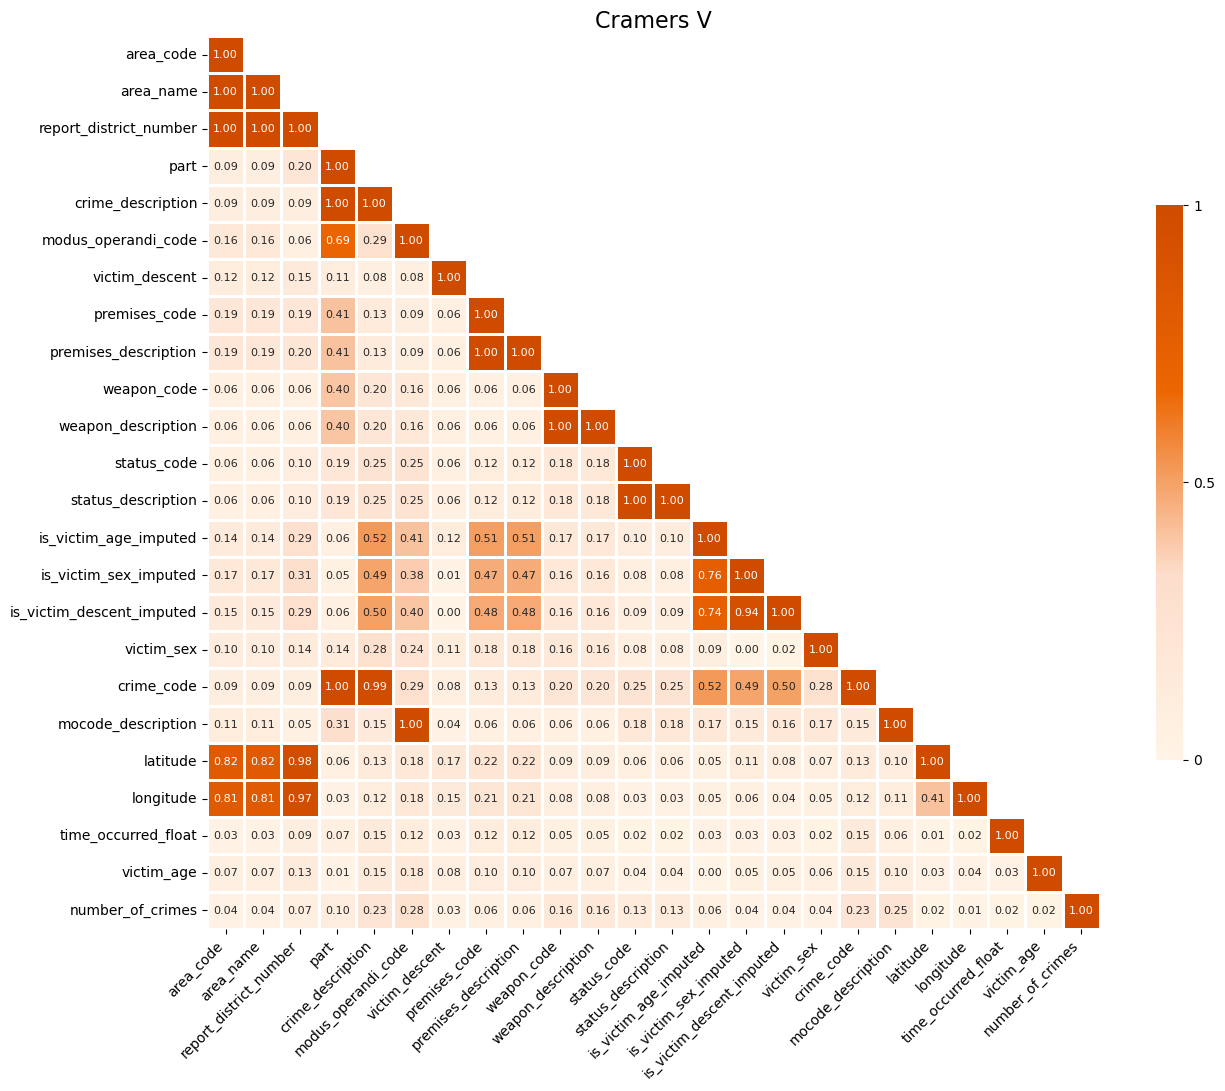

In [5]:
cat_corr_heatmap(matrix)

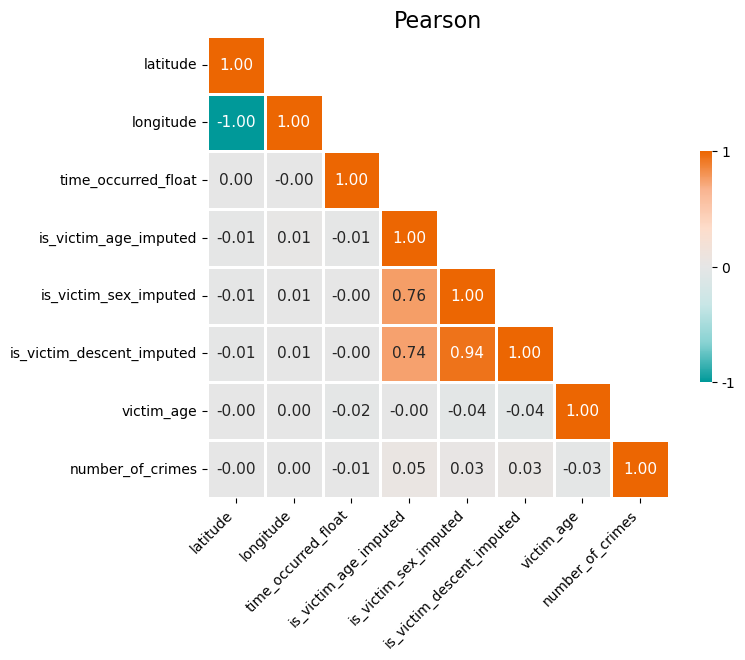

In [6]:
num_corr_heatmap(df.corr(numeric_only=True))